In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import os

BASE_PATH = '...'
CSV_PATH  = os.path.join(BASE_PATH, 'Combined.csv')
OUT_PATH  = BASE_PATH

print(f'CSV path : {CSV_PATH}')
print(f'Exists   : {os.path.exists(CSV_PATH)}')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
CSV path : /content/drive/MyDrive/Dataset/5G-NIDD/Combined.csv
Exists   : True


In [26]:
import pandas as pd
import numpy as np
import time
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Conv1D, MaxPooling1D, Flatten, Dense, TimeDistributed, Lambda
from tensorflow.keras.utils import to_categorical

In [27]:
df = pd.read_csv(CSV_PATH, low_memory=False)

# Replace inf
df.replace([np.inf, -np.inf], np.nan, inplace=True)

# Binary label: 0 = Benign, 1 = Attack
df['label'] = (df['Label'] != 'Benign').astype(int)

print(f'Shape   : {df.shape}')
print(f'\nLabel distribution:')
print(df['label'].value_counts())

Shape   : (1215890, 53)

Label distribution:
label
1    738153
0    477737
Name: count, dtype: int64


In [ ]:
selected_features = [
    'sTtl', 'DstRate', 'SrcGap', 'Rate', 'SrcRate', 'TotPkts', 'SrcWin',
    'DstWin', 'Load', 'dTtl', 'TotBytes', 'DstPkts', 'DstLoad', 'Dur',
    'sMeanPktSz', 'SrcLoss', 'pLoss', 'DstBytes', 'sTos', 'SrcPkts',
    'Sum', 'SrcTCPBase', 'SynAck', 'Mean', 'RunTime', 'Max', 'DstGap',
    'TcpRtt', 'AckDat', 'dHops', 'Loss', 'Min', 'Seq', 'dTos', 'Offset'
]

print(f"Total features: {len(selected_features)}")

df_feat = df[selected_features].copy()
df_temp = df_feat.fillna(0)
zero_var_cols = df_temp.columns[df_temp.var() == 0].tolist()
print(f'Kolom variance=0 (di-drop): {zero_var_cols}')
df_feat = df_feat.drop(columns=zero_var_cols)
selected_features = df_feat.columns.tolist()
for col in df_feat.columns:
    if df_feat[col].isna().any():
        median_val = df_feat[col].median()
        df_feat[col] = df_feat[col].fillna(median_val)

df = pd.concat([df_feat, df['label']], axis=1)
df.reset_index(drop=True, inplace=True)

print(f'Shape after imputation : {df.shape}')
print(f'Features               : {selected_features}')
print(f'Remaining NaN          : {df.isna().sum().sum()}')

In [29]:
X_raw = df[selected_features].values
y_raw = df['label'].values

scaler   = StandardScaler()
X_scaled = scaler.fit_transform(X_raw)

In [30]:
print(f'X_raw shape : {X_raw.shape}')

X_raw shape : (1215890, 35)


In [ ]:
def ensure_3d_X(X):
    X = np.asarray(X)
    if X.ndim == 2:
        X = X.astype(np.float32)[..., np.newaxis]
    elif X.ndim == 3:
        X = X.astype(np.float32)
    else:
        raise ValueError(f'X must be 2D/3D. Got: {X.shape}')
    return X

def ensure_y_shape(y):
    y = np.asarray(y)
    if y.dtype == object:
        le = LabelEncoder()
        y = le.fit_transform(y)
    if not np.issubdtype(y.dtype, np.integer):
        y = y.astype(int)
    classes = np.unique(y)
    if len(classes) == 2 and set(classes) <= {0, 1}:
        y = y.reshape(-1, 1).astype(np.float32)
    else:
        y = to_categorical(y.astype(int)).astype(np.float32)
    return y

X = ensure_3d_X(X_scaled)
y = ensure_y_shape(y_raw)


In [32]:
class JaspenCorrelation(tf.keras.layers.Layer):
    def __init__(self, **kwargs):
        super().__init__(**kwargs)

    def call(self, t, r):
        t_exp  = tf.expand_dims(t, 1)
        dot    = tf.reduce_sum(t_exp * r, axis=-1)
        norm_t = tf.norm(t_exp, axis=-1)
        norm_r = tf.norm(r,     axis=-1)
        corr   = dot / (norm_t * norm_r + 1e-8)
        corr   = tf.maximum(corr, 0.0)
        return tf.reduce_mean(corr, axis=1, keepdims=True)

    def get_config(self):
        return super().get_config()


def create_model(ref_count, seq_len, channels, num_classes, is_multiclass):
    test_input      = Input(shape=(seq_len, channels), name='test_input')
    reference_input = Input(shape=(ref_count, seq_len, channels), name='reference_input')

    # seq_len=10: Conv1D(k=3) -> 8, satu MaxPooling1D(2) -> 4, cukup
    shared_cnn = tf.keras.Sequential([
        Conv1D(64, 3, activation='relu', padding='same'),
        MaxPooling1D(2),
        Conv1D(128, 3, activation='relu', padding='same'),
        Flatten()
    ], name='shared_cnn')

    test_encoded      = shared_cnn(test_input)
    reference_encoded = TimeDistributed(shared_cnn)(reference_input)

    agg = JaspenCorrelation()(test_encoded, reference_encoded)

    x = Dense(128, activation='relu')(agg)

    if is_multiclass:
        output = Dense(num_classes, activation='softmax')(x)
        loss   = 'categorical_crossentropy'
    else:
        output = Dense(num_classes, activation='sigmoid')(x)
        loss   = 'binary_crossentropy'

    model = Model(inputs=[test_input, reference_input], outputs=output)
    return model, loss

In [33]:
def calculate_all_metrics(y_true, y_pred, is_multiclass, threshold=0.5):
    if is_multiclass:
        y_true_cls = np.argmax(y_true, axis=1)
        y_pred_cls = np.argmax(y_pred, axis=1)
        acc  = accuracy_score(y_true_cls, y_pred_cls)
        prec = precision_score(y_true_cls, y_pred_cls, average='macro', zero_division=0)
        rec  = recall_score(y_true_cls, y_pred_cls, average='macro', zero_division=0)
        f1   = f1_score(y_true_cls, y_pred_cls, average='macro', zero_division=0)
    else:
        y_pred_bin = (y_pred >= threshold).astype(int)
        average    = 'binary' if y_true.shape[1] == 1 else 'macro'
        acc  = accuracy_score(y_true, y_pred_bin)
        prec = precision_score(y_true, y_pred_bin, average=average, zero_division=0)
        rec  = recall_score(y_true, y_pred_bin, average=average, zero_division=0)
        f1   = f1_score(y_true, y_pred_bin, average=average, zero_division=0)
    return {
        'Accuracy' : acc  * 100.0,
        'Precision': prec * 100.0,
        'Recall'   : rec  * 100.0,
        'F1_Score' : f1   * 100.0
    }


def calculate_space_per_instance_broadcast(X_sample, y_sample):
    return (X_sample.nbytes + y_sample.nbytes) / (1024 * 1024)

def reference_set_size_mb(reference_set):
    return reference_set.nbytes / (1024 * 1024)

def measure_single_instance_time(model, X_sample, reference_set, num_trials=5):
    ref_input = np.broadcast_to(reference_set[np.newaxis, ...], (1,) + reference_set.shape)
    _ = model.predict([X_sample, ref_input], verbose=0)
    times = []
    for _ in range(num_trials):
        t0 = time.time()
        _ = model.predict([X_sample, ref_input], verbose=0)
        times.append((time.time() - t0) * 1000.0)
    return float(np.mean(times))

In [34]:
def run_full_data(X, y, ref_count_fixed=20, epochs=10, batch_size=16,
                  test_size=0.2, random_state=42):
    assert X.shape[0] == y.shape[0]
    N, SEQ_LEN, CHANNELS = X.shape[0], X.shape[1], X.shape[2]
    NUM_CLASSES   = y.shape[1]
    is_multiclass = (
        (NUM_CLASSES > 1) and
        np.all((y == 0) | (y == 1)) and
        np.all(y.sum(axis=1) == 1)
    )

    X = X.astype(np.float32)
    y = y.astype(np.float32)

    print('=' * 70)
    print(f'Running on full data: N = {N:,}')
    print('=' * 70)

    if is_multiclass:
        y_strat = np.argmax(y, axis=1)
    else:
        y_strat = y.squeeze()

    X_train_s, X_test_s, y_train_s, y_test_s = train_test_split(
        X, y, test_size=test_size, stratify=y_strat, random_state=random_state
    )

    # Class weight untuk handle imbalance
    y_train_1d = y_train_s.ravel().astype(int)
    classes, counts = np.unique(y_train_1d, return_counts=True)
    total = len(y_train_1d)
    class_weight = {int(c): total / (len(classes) * cnt) for c, cnt in zip(classes, counts)}
    print(f'Class weight: {class_weight}')

    ref_count     = min(ref_count_fixed, len(X_train_s))
    reference_set = X_train_s[:ref_count]

    ref_train = np.broadcast_to(
        reference_set[np.newaxis, ...], (X_train_s.shape[0],) + reference_set.shape
    )
    ref_test = np.broadcast_to(
        reference_set[np.newaxis, ...], (X_test_s.shape[0],) + reference_set.shape
    )

    model, loss = create_model(ref_count, SEQ_LEN, CHANNELS, NUM_CLASSES, is_multiclass)
    model.compile(optimizer='adam', loss=loss, metrics=['accuracy'])

    X_sample = X_train_s[0:1]
    y_sample = y_train_s[0:1]
    space_per_instance = calculate_space_per_instance_broadcast(X_sample, y_sample)
    S_com = N * space_per_instance + reference_set_size_mb(reference_set)

    t0 = time.time()
    history=model.fit(
        [X_train_s, ref_train], y_train_s,
        validation_data=([X_test_s, ref_test], y_test_s),
        epochs=epochs, batch_size=batch_size, verbose=1,
        class_weight=class_weight
    )
    train_time = time.time() - t0

    pred_start      = time.time()
    y_pred          = model.predict([X_test_s, ref_test], verbose=0)
    metrics         = calculate_all_metrics(y_test_s, y_pred, is_multiclass)
    prediction_time = time.time() - pred_start

    tpi   = measure_single_instance_time(model, X_sample, reference_set, num_trials=5)
    T_com = N * tpi

    print(f'\nREF_COUNT used           : {ref_count}')
    print(f'Train size               : {X_train_s.shape[0]:,}')
    print(f'Test size                : {X_test_s.shape[0]:,}')
    print(f'Train time (s)           : {train_time:.2f}')
    print(f'Acc / Prec / Rec / F1 (%): '
          f'{metrics["Accuracy"]:.2f} / {metrics["Precision"]:.2f} / '
          f'{metrics["Recall"]:.2f} / {metrics["F1_Score"]:.2f}')
    print(f'T_com (ms)               : {T_com:.2f}')
    print(f'S_com (MB)               : {S_com:.2f}')
    print(f'Prediction time (s)      : {prediction_time:.2f}')

    return {
        'N'                  : N,
        'ref_count'          : ref_count,
        'accuracy'           : metrics['Accuracy'],
        'precision'          : metrics['Precision'],
        'recall'             : metrics['Recall'],
        'f1_score'           : metrics['F1_Score'],
        'training_time'      : train_time,
        'time_complexity_ms' : T_com,
        'space_complexity_mb': S_com,
        'prediction_time'    : prediction_time,
        'model'              : model,
        'history'            : history
    }

In [35]:
import tensorflow as tf
print(tf.__version__)
print(tf.keras.__version__)

2.20.0
3.13.2


In [39]:
print(X.shape, y.shape, X.dtype, y.dtype)

results = run_full_data(
    X, y,
    ref_count_fixed=20,
    epochs=10,
    batch_size=16
)

(1215890, 35, 1) (1215890, 1) float32 float32
Running on full data: N = 1,215,890
Class weight: {0: np.float64(1.2725503022057092), 1: np.float64(0.8236035236621159)}
Epoch 1/10
60795/60795 ━━━━━━━━━━━━━━━━━━━━ 311s 5ms/step - accuracy: 0.9143 - loss: 0.2454 - val_accuracy: 0.9809 - val_loss: 0.0712
Epoch 2/10
60795/60795 ━━━━━━━━━━━━━━━━━━━━ 298s 5ms/step - accuracy: 0.9832 - loss: 0.0582 - val_accuracy: 0.9836 - val_loss: 0.0682
Epoch 3/10
60795/60795 ━━━━━━━━━━━━━━━━━━━━ 300s 5ms/step - accuracy: 0.9947 - loss: 0.0227 - val_accuracy: 0.9964 - val_loss: 0.0189
Epoch 4/10
60795/60795 ━━━━━━━━━━━━━━━━━━━━ 303s 5ms/step - accuracy: 0.9947 - loss: 0.0185 - val_accuracy: 0.9935 - val_loss: 0.0203
Epoch 5/10
60795/60795 ━━━━━━━━━━━━━━━━━━━━ 303s 5ms/step - accuracy: 0.9947 - loss: 0.0194 - val_accuracy: 0.9956 - val_loss: 0.0157
Epoch 6/10
60795/60795 ━━━━━━━━━━━━━━━━━━━━ 304s 5ms/step - accuracy: 0.9954 - loss: 0.0175 - val_accuracy: 0.9939 - val_loss: 0.0271
Epoch 7/10
60795/60795 ━━━━━━

In [40]:
print(f"Total Data (N)      : {results['N']:,}")
print(f"Ref Count           : {results['ref_count']}")
print(f"Accuracy (%)        : {results['accuracy']:.2f}")
print(f"Precision (%)       : {results['precision']:.2f}")
print(f"Recall (%)          : {results['recall']:.2f}")
print(f"F1 Score (%)        : {results['f1_score']:.2f}")
print(f"Training Time (s)   : {results['training_time']:.2f}")
print(f"T_com (ms)          : {results['time_complexity_ms']:.2f}")
print(f"S_com (MB)          : {results['space_complexity_mb']:.2f}")
print(f"Prediction Time (s) : {results['prediction_time']:.2f}")

Total Data (N)      : 1,215,890
Ref Count           : 20
Accuracy (%)        : 99.26
Precision (%)       : 99.86
Recall (%)          : 98.93
F1 Score (%)        : 99.39
Training Time (s)   : 3031.44
T_com (ms)          : 110731837.09
S_com (MB)          : 166.98
Prediction Time (s) : 23.45


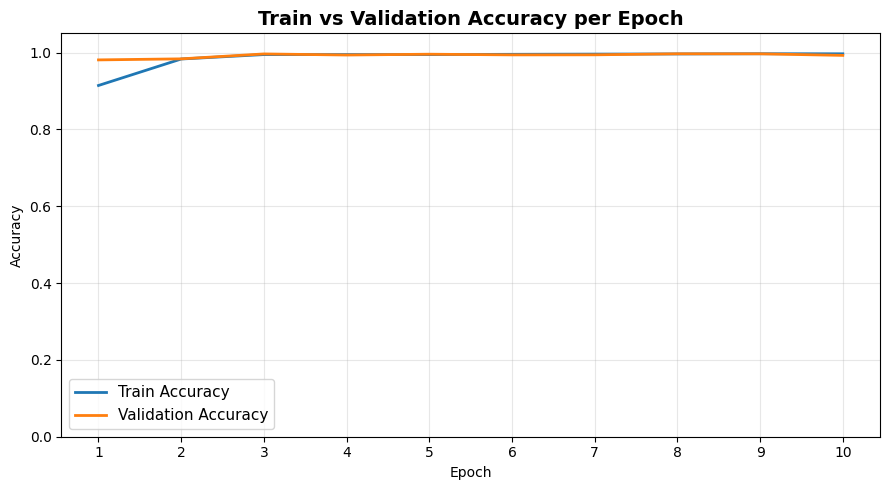

In [41]:
import matplotlib.pyplot as plt

history = results['history']

train_acc = history.history['accuracy']
val_acc   = history.history['val_accuracy']
epochs_range = range(1, len(train_acc) + 1)

plt.figure(figsize=(9, 5))
plt.plot(epochs_range, train_acc, linewidth=2, label='Train Accuracy')
plt.plot(epochs_range, val_acc,  linewidth=2, label='Validation Accuracy', )
plt.title('Train vs Validation Accuracy per Epoch', fontsize=14, fontweight='bold')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.xticks(epochs_range)
plt.ylim(0, 1.05)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()